In [32]:
import pandas as pd


In [33]:
from google.colab import files
uploaded = files.upload()

Saving student_scores.csv to student_scores (1).csv


In [34]:
df = pd.read_csv("student_scores.csv")


In [35]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [36]:
df.shape


(25, 2)

In [37]:
df.columns

Index(['Hours', 'Scores'], dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [39]:
df.isnull().sum()

,0
Hours,0
Scores,0


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


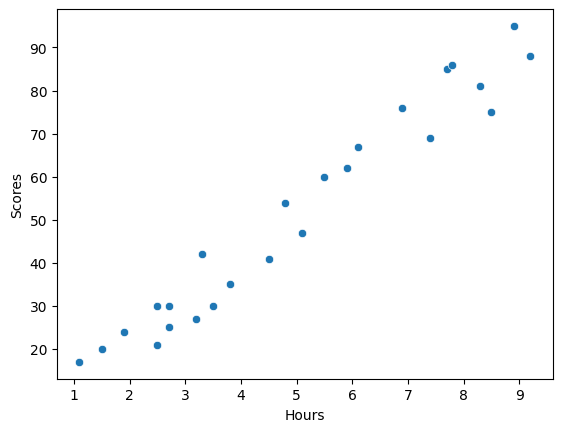

In [43]:
sns.scatterplot(x = df.iloc[ :, 0], y=df.iloc[:, 1])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [44]:
df.corr(numeric_only=True)

,Hours,Scores
Hours,1.000000,0.976191
Scores,0.976191,1.000000


In [45]:
X = df.iloc[:, 0].values.reshape(-1, 1)
y = df.iloc[:, 1].values

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [47]:
X_train.shape, X_test.shape

((20, 1), (5, 1))

In [48]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [49]:
model.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred = model.predict(X_test)

In [51]:
y_pred

array([83.18814104, 27.03208774, 27.03208774, 69.63323162, 59.95115347])

In [52]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,81,83.188141
1,30,27.032088
2,21,27.032088
3,76,69.633232
4,62,59.951153


In [53]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3.9207511902099244


In [54]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 18.943211722315272


In [55]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 4.352380006653288


In [56]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9678055545167994


In [57]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9.682078154455697
Intercept: 2.826892353899737


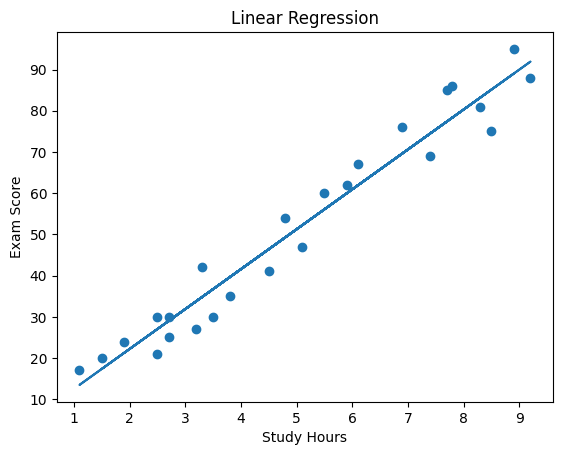

In [58]:
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.show()

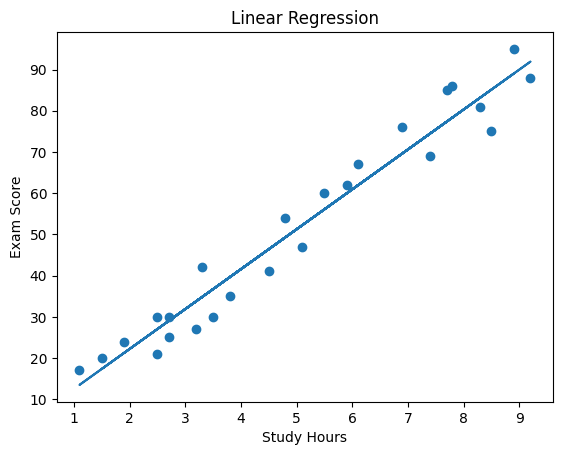

In [59]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.show()

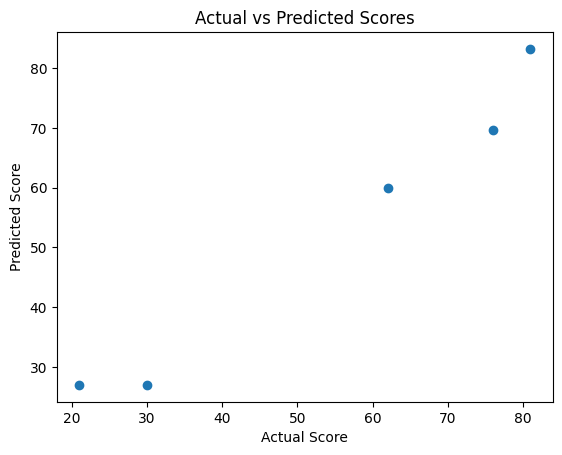

In [60]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

In [62]:
residuals = y_test - y_pred

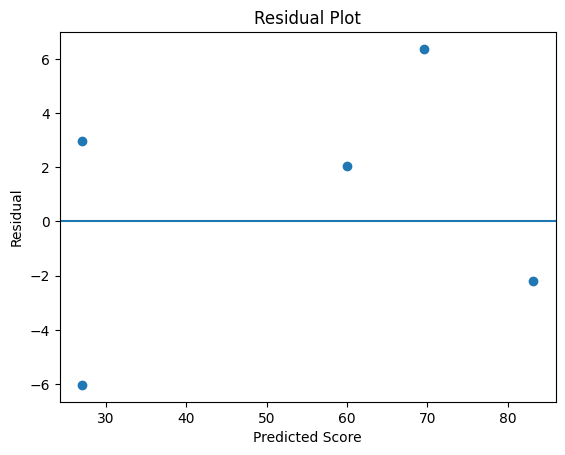

In [63]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [64]:
train_r2 = model.score(X_train, y_train)
print("Training R²:", train_r2)

Training R²: 0.9491209376364416


In [65]:
test_r2 = model.score(X_test, y_test)
print("Testing R²:", test_r2)

Testing R²: 0.9678055545167994


In [66]:
print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9491209376364416
Testing R²: 0.9678055545167994


In [67]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", cv_scores)
print("Average R²:", cv_scores.mean())

Cross-validation R² scores: [0.78626426 0.97891923 0.93182467 0.96604831 0.9273292 ]
Average R²: 0.9180771341891051


In [68]:
new_hours = [[7]]

predicted_score = model.predict(new_hours)

print("Predicted Exam Score:", predicted_score[0])

Predicted Exam Score: 70.60143943508962


In [69]:
new_hours = [[10]]

predicted_score = model.predict(new_hours)

print("Predicted Exam Score:", predicted_score[0])

Predicted Exam Score: 99.6476738984567


In [70]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9.682078154455697
Intercept: 2.826892353899737


In [71]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [72]:
loaded_model = joblib.load("linear_regression_model.pkl")

In [73]:
new_hours = [[7]]

prediction = loaded_model.predict(new_hours)

print("Predicted Score:", prediction[0])

Predicted Score: 70.60143943508962


In [74]:
import os

os.listdir()

['.config',
 'linear_regression_model.pkl',
 'student_scores (1).csv',
 'student_scores.csv',
 'sample_data']